In [1]:
#import libs
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import durbin_watson
from scipy import stats

import warnings

warnings.filterwarnings('ignore')

print('All libraries imported successfully.')


All libraries imported successfully.


In [2]:

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Task 1: Data Pre-processing and Statistical Description
(i)  Pre-process the collected data, including data cleaning, missing data detection, and preparation.

In [3]:
# file path to import data
data_path = '/content/drive/MyDrive/Colab Notebooks/ECS4002_CW2/ECS4002_CW2_Data.xlsx'
orig_data = pd.read_excel(data_path, header=1)
display(orig_data)

,Date,PM2.5,NO2,O3,temperature,humidity
0,18/10/2018,14.151020,90.334694,114.322449,18.416327,39.269388
1,18/10/2018,12.477816,90.399317,98.525597,18.163823,40.498294
2,18/10/2018,12.706161,114.649289,82.905213,17.208531,43.066351
3,18/10/2018,6.683333,66.583333,39.944444,16.205556,46.655556
4,18/10/2018,6.492958,66.868545,34.319249,15.032864,49.352113
...,...,...,...,...,...,...
461,06/11/2018,NaN,NaN,NaN,NaN,NaN
462,06/11/2018,NaN,NaN,NaN,NaN,NaN
463,06/11/2018,NaN,NaN,NaN,NaN,NaN
464,06/11/2018,NaN,NaN,NaN,NaN,NaN


Missing data detection:

In [4]:
# count NaN values in each column
print("Missing values per column:")
print(orig_data.isnull().sum())

# show the rows with missing data (NaN)
nan_rows = orig_data[orig_data.isnull().any(axis=1)]
#display(nan_rows)

Missing values per column:
Date            0
PM2.5          14
NO2            14
O3             14
temperature    14
humidity       14
dtype: int64


In [5]:
# drop rows with NaNs
cleaned_data = orig_data.dropna()
print(f"Original rows: {len(orig_data)}")
print(f"Removed NaN values - rows: {len(cleaned_data)}")
#display(cleaned_data.head())
data = cleaned_data

Original rows: 466
Removed NaN values - rows: 452


Add hour column:

In [6]:
# add hour column to raw data
data['Date'] = pd.to_datetime(data['Date'], dayfirst=True)
# get the first date
first_day = data['Date'].min()
# apply 1-24 hours
def hour(group):
    n = len(group)
    # configure first day hours to start at 15
    if group.name == first_day:
        start_hour = 24 - n + 1
        group['Hour'] = range(start_hour, 25)
    else:
        # start at hour 1 for other days
        group['Hour'] = range(1, n + 1)
    return group

data = data.groupby('Date', group_keys=False).apply(hour)
# add hour column
cols = ['Date', 'Hour'] + [c for c in data.columns if c not in ['Date', 'Hour']]
data = data[cols]
# check data
# display(data.head(20))
# display(data.tail(20))

Rename columns to include units for clarity:

(ii) Perform basic statistical analysis on the raw data, such as descriptive statistics including mean, standard deviation, quartiles, and box plots.

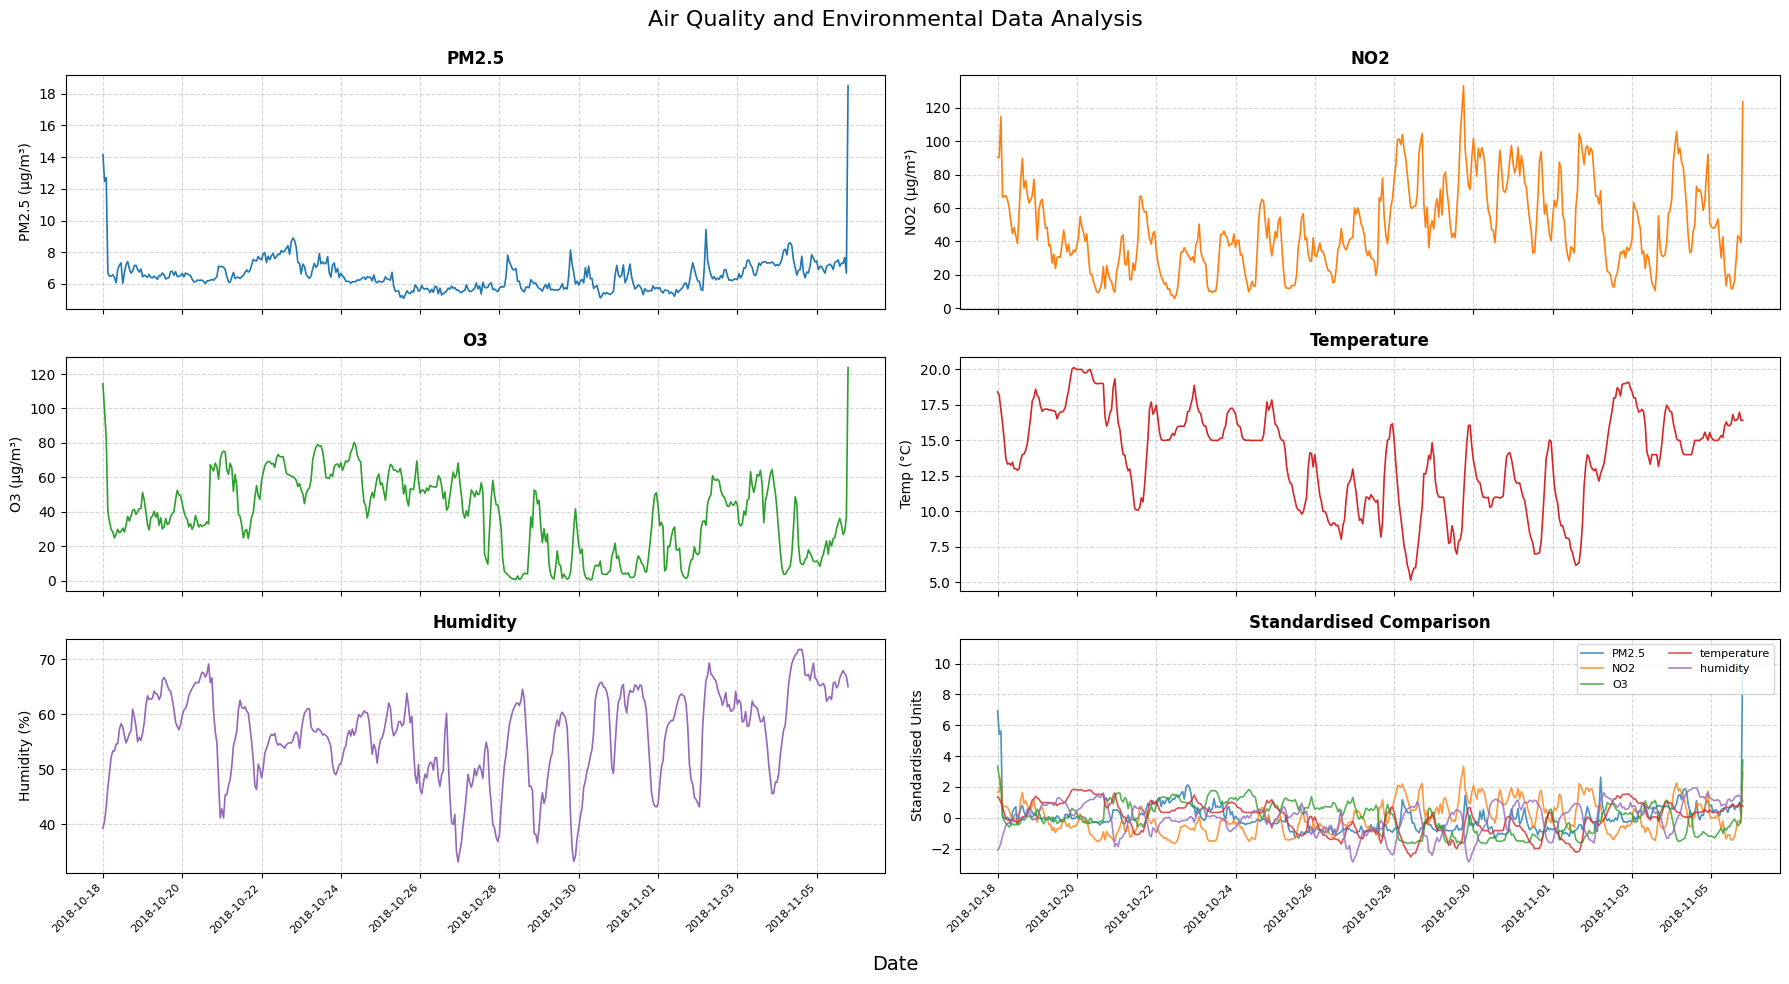

In [7]:
# raw data and standardised data plots
scaler = StandardScaler()
variables = ['PM2.5', 'NO2', 'O3', 'temperature', 'humidity']
label_mapping = {
    'PM2.5': 'PM2.5 (µg/m³)', 'NO2': 'NO2 (µg/m³)', 'O3': 'O3 (µg/m³)',
    'temperature': 'Temp (°C)', 'humidity': 'Humidity (%)'
}
data_std = data.copy()
data_std[variables] = scaler.fit_transform(data[variables])
data['Timeline'] = data.index
data_std['Timeline'] = data_std.index
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 2)

axes = [fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]),
        fig.add_subplot(gs[1, 0]), fig.add_subplot(gs[1, 1]),
        fig.add_subplot(gs[2, 0])]
ax_big = fig.add_subplot(gs[2, 1])

step = 48
x_ticks = data['Timeline'][::step]
x_labels = data['Date'].dt.strftime('%Y-%m-%d')[::step]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, col in enumerate(variables):
    ax = axes[i]
    ax.plot(data['Timeline'], data[col], color=colors[i], linewidth=1.2)
    ax.set_title(col.capitalize() if col != 'PM2.5' and col != 'NO2' and col != 'O3' else col, fontweight='bold', fontsize=12, pad=8)
    ax.set_ylabel(label_mapping[col], fontsize=10)
    ax.set_xticks(x_ticks)
    ax.grid(True, linestyle='--', alpha=0.5)

    if i < 4:
        ax.set_xticklabels([])
    else:
        ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
for i, col in enumerate(variables):
    ax_big.plot(data_std['Timeline'], data_std[col], label=col, linewidth=1.2, alpha=0.8)

ax_big.set_title('Standardised Comparison', fontweight='bold', fontsize=12, pad=8)
ax_big.set_xticks(x_ticks)
ax_big.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
ax_big.set_ylabel('Standardised Units', fontsize=10)
ax_big.legend(loc='upper right', fontsize=8, ncol=2)
ax_big.grid(True, linestyle='--', alpha=0.5)
fig.suptitle('Air Quality and Environmental Data Analysis', fontsize=16, y=0.97)
fig.text(0.5, 0.01, 'Date', ha='center', fontsize=14)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

Mean Calculation, Standard Deviation, Quartiles and Box Plots



In [8]:
selected_columns_for_analysis = ['PM2.5', 'temperature', 'humidity', 'NO2', 'O3']

print("\nSummary statistics for selected columns:")
print(data[selected_columns_for_analysis].describe())


Summary statistics for selected columns:
            PM2.5  temperature    humidity         NO2          O3
count  452.000000   452.000000  452.000000  452.000000  452.000000
mean     6.543324    13.829337   56.174169   48.247588   38.451131
std      1.095475     3.417949    8.049601   25.380811   22.811037
min      5.093939     5.158537   33.107143    5.973134    0.346269
25%      5.805357    11.012085   50.763937   30.588979   18.298002
50%      6.409358    14.414666   57.176818   43.441374   39.999008
75%      7.044404    16.401366   62.381606   64.800078   55.826112
max     18.500000    20.131343   71.770833  133.128834  123.755556


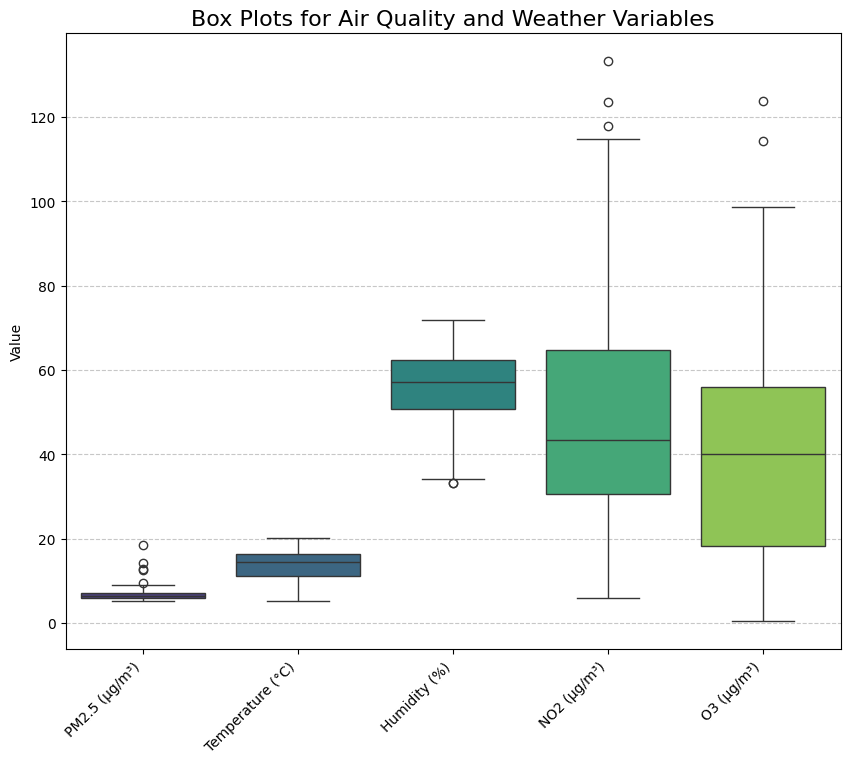

In [9]:
# single box plot for all selected columns
plt.figure(figsize=(10, 8))
sns.boxplot(data=data[selected_columns_for_analysis], palette='viridis')
plt.title('Box Plots for Air Quality and Weather Variables', fontsize=16)
plt.ylabel('Value')
plt.grid(axis='y', linestyle='--', alpha=0.7)

new_labels = [
    'PM2.5 (µg/m³)',
    'Temperature (°C)',
    'Humidity (%)',
    'NO2 (µg/m³)',
    'O3 (µg/m³)'
]
plt.xticks(ticks=range(len(selected_columns_for_analysis)), labels=new_labels, rotation=45, ha='right')
plt.show()

(iii) Perform advanced statistical analysis, such as correlation analysis and distribution analysis, to explore relationships and patterns in the data.

Correlation Analysis

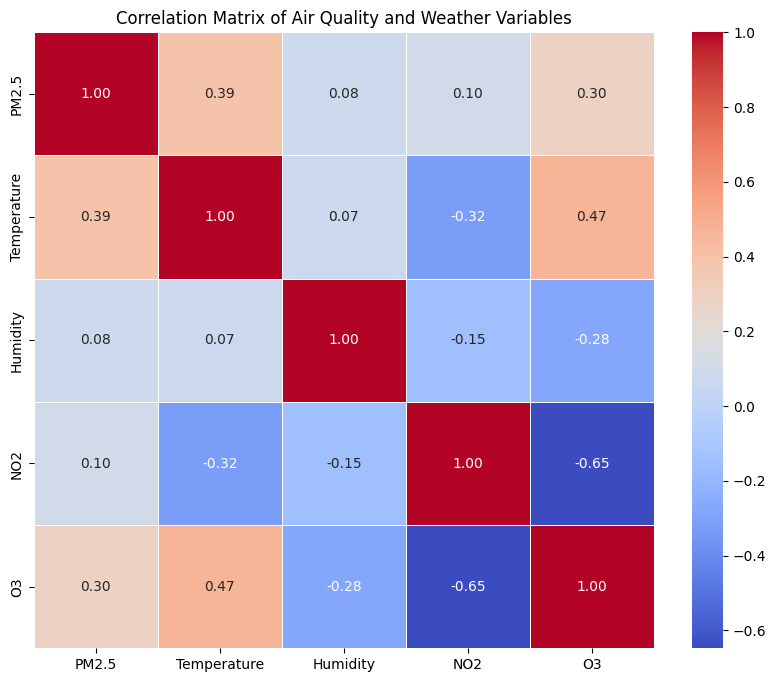

In [10]:
# correlation matrix
correlation_matrix = data[selected_columns_for_analysis].corr()

heatmap_labels = {
    'PM2.5': 'PM2.5',
    'temperature': 'Temperature',
    'humidity': 'Humidity',
    'NO2': 'NO2',
    'O3': 'O3'
}

plot_corr = correlation_matrix.rename(index=heatmap_labels, columns=heatmap_labels)
plt.figure(figsize=(10, 8))
sns.heatmap(plot_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Air Quality and Weather Variables')
plt.show()

Distribution Analysis

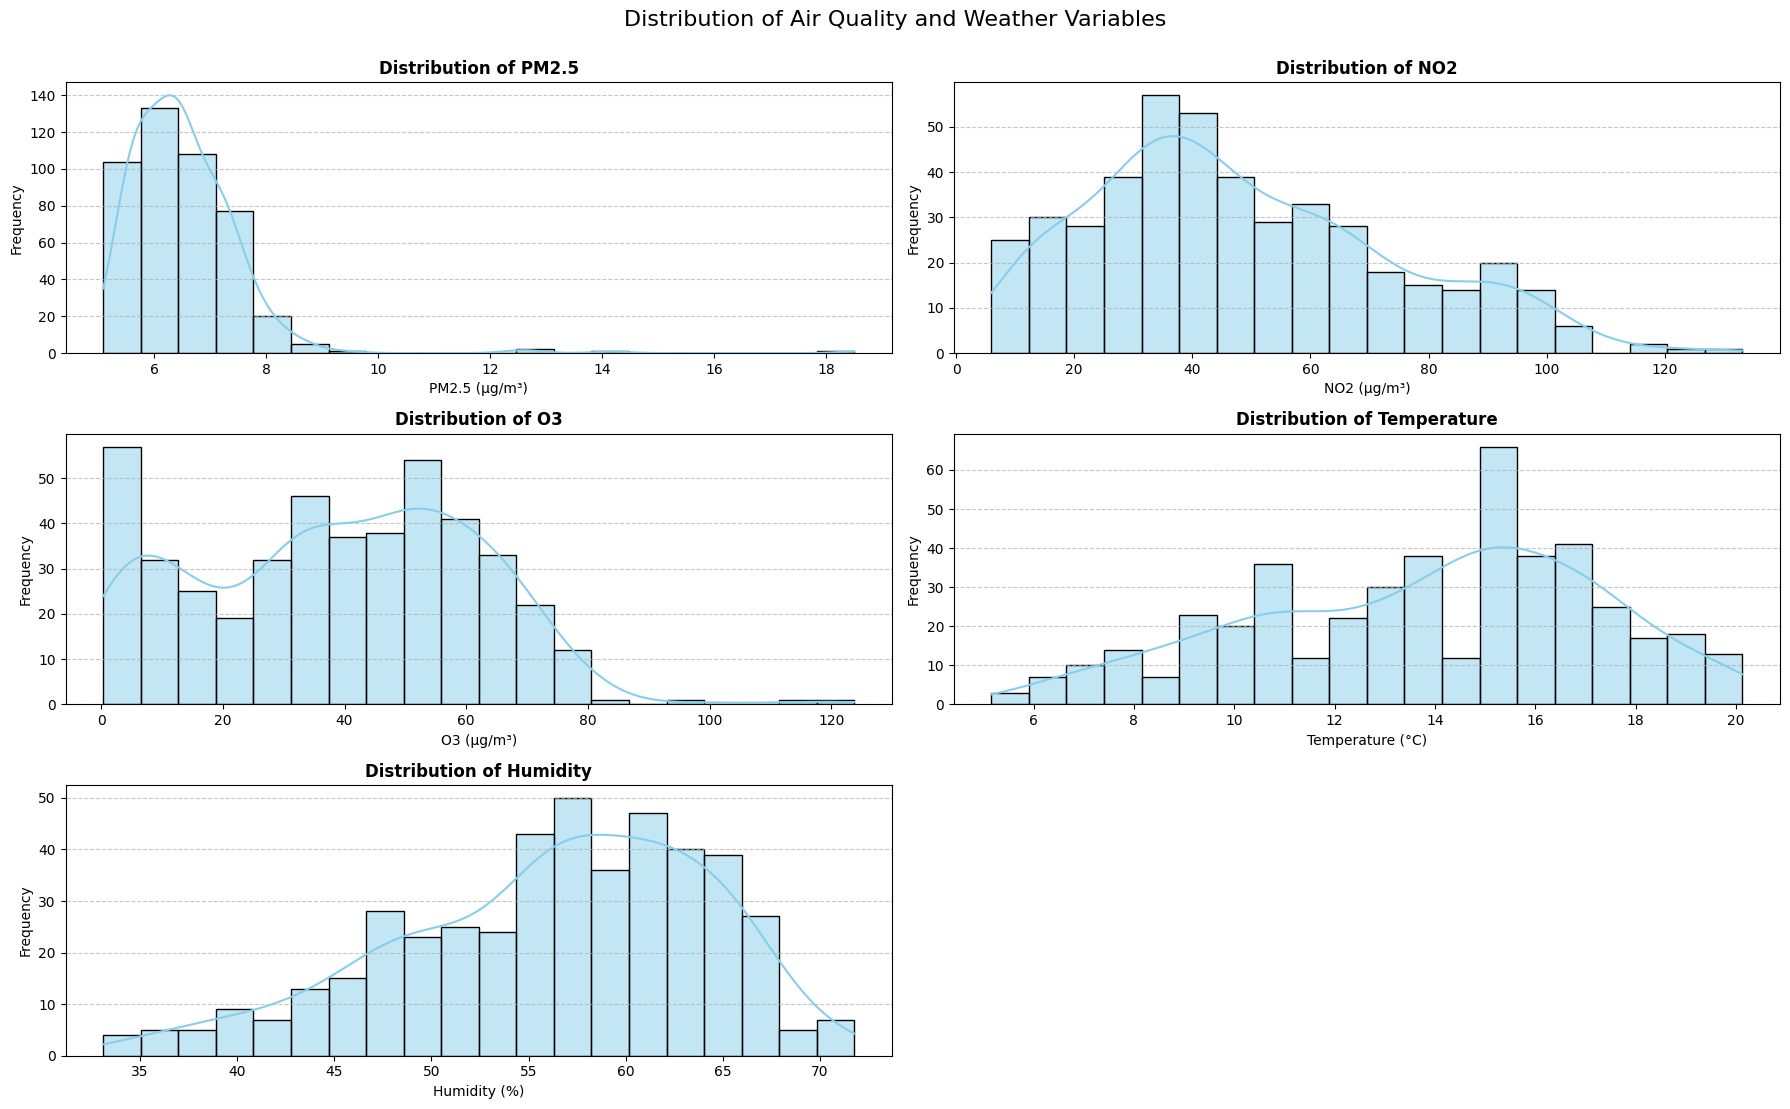

In [11]:
# distribution plots
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2)

labels_with_units = {
    'PM2.5': {'label': 'PM2.5', 'unit': 'µg/m³'},
    'NO2': {'label': 'NO2', 'unit': 'µg/m³'},
    'O3': {'label': 'O3', 'unit': 'µg/m³'},
    'temperature': {'label': 'Temperature', 'unit': '°C'},
    'humidity': {'label': 'Humidity', 'unit': '%'}
}

ax00 = fig.add_subplot(gs[0, 0])
ax01 = fig.add_subplot(gs[0, 1])
ax10 = fig.add_subplot(gs[1, 0])
ax11 = fig.add_subplot(gs[1, 1])
ax20 = fig.add_subplot(gs[2, 0])

ax_dummy = fig.add_subplot(gs[2, 1])
ax_dummy.axis('off')

axes = [ax00, ax01, ax10, ax11, ax20]

fig.suptitle('Distribution of Air Quality and Weather Variables', fontsize=16, y=0.95)

variables_for_dist = ['PM2.5', 'NO2', 'O3', 'temperature', 'humidity']

for i, col in enumerate(variables_for_dist):
    sns.histplot(data[col], kde=True, ax=axes[i], color='skyblue', bins=20)
    info = labels_with_units[col]
    axes[i].set_title(f'Distribution of {info["label"]}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(f'{info["label"]} ({info["unit"]})', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Task 2: Multiple Regression Model Development
(i) Develop a forecasting model using multiple linear regression, in which a dependent variable is predicted from multiple independent variables.

In [12]:
predictors = ['NO2', 'PM2.5', 'temperature', 'humidity']
pred_units = ['ug/m^3', 'ug/m^3', 'degC', '%']

X = data[predictors]
X_const = sm.add_constant(X)

vif_data = pd.DataFrame()
vif_data['Feature'] = X.columns
vif_data['VIF'] = [variance_inflation_factor(X_const.values, i+1) for i in range(len(X.columns))]
vif_data['Concern'] = vif_data['VIF'].apply(lambda v: 'High' if v > 10 else ('Moderate' if v > 5 else 'OK'))

print('Variance Inflation Factors (VIF > 10 indicates severe multicollinearity):')
print(vif_data.to_string(index=False))

# ======= 1. Prepare Data for One-Step-Ahead Forecasting =======
df_forecast = data.copy()

# Create the target variable: O3 at time (t+1)
# .shift(-1) moves all actual O3 values UP by one row
df_forecast['O3_Target_Next_Hour'] = df_forecast['O3'].shift(-1)

# Drop the very last row, as we cannot predict past the end of our dataset
df_forecast = df_forecast.dropna()

# ======= 2. Define Features (t) and Target (t+1) =======
# CRITICAL: We now include current 'O3' as a predictor to fix autocorrelation
predictors = ['O3', 'NO2', 'PM2.5', 'temperature', 'humidity']

X = df_forecast[predictors].values
y = df_forecast['O3_Target_Next_Hour'].values

# ======= 3. Train / Test split (80/20 Chronological) =======
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print(f'Training set: {X_train.shape[0]} samples')
print(f'Test set: {X_test.shape[0]} samples')



Variance Inflation Factors (VIF > 10 indicates severe multicollinearity):
    Feature      VIF Concern
        NO2 1.232098      OK
      PM2.5 1.287322      OK
temperature 1.409229      OK
   humidity 1.033159      OK
Training set: 360 samples
Test set: 91 samples


In [13]:
# ======= Fit OLS model using statsmodels for full statistical output =======
X_train_sm = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_sm).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.918
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     792.2
Date:                Fri, 24 Apr 2026   Prob (F-statistic):          9.61e-190
Time:                        20:26:23   Log-Likelihood:                -1190.1
No. Observations:                 360   AIC:                             2392.
Df Residuals:                     354   BIC:                             2416.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.1304      4.409      2.071      0.0

## Task 3: Multiple Regression Model Evaluation

In [14]:
# ======= Predictions on test set =======
X_test_sm = sm.add_constant(X_test)
y_pred    = ols_model.predict(X_test_sm)

# ======= Metrics =======
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)

# ======= Calculate MAPE (returns a decimal, e.g., 0.15 for 15%) =======
mape = mean_absolute_percentage_error(y_test, y_pred)

# =======Multiply by 100 to print it as a readable percentage=======
print(f"Test MAPE: {mape * 100:.1f}%")

metrics = pd.DataFrame({'Metric': ['R²', 'RMSE (µg/m³)', 'MAE (µg/m³)'],
                         'Value':  [f'{r2:.4f}', f'{rmse:.4f}', f'{mae:.4f}']})
print('Test Set Performance:')
print(metrics.to_string(index=False))

Test MAPE: 20.9%
Test Set Performance:
      Metric   Value
          R²  0.6819
RMSE (µg/m³) 11.3508
 MAE (µg/m³)  5.8830


In [15]:
residuals = y_test - y_pred

# ======= Statistical tests on residuals =======

# S-W normality test (sample of 200 to meet test requirements)
sample_res = residuals[:200] if len(residuals) > 200 else residuals
stat_sw, p_sw = stats.shapiro(sample_res)

# Durbin autocorrelation test
dw_stat = durbin_watson(residuals)

print('=== Residual Statistical Tests ===')
print(f'Shapiro-Wilk test:  W = {stat_sw:.4f},  p = {p_sw:.4f}')
print(f'  → Residuals are {"NOT " if p_sw < 0.05 else ""}normally distributed at α=0.05')
print()
print(f'Durbin-Watson stat: {dw_stat:.4f}')
print(f'  → {"Little to no autocorrelation" if 1.5 < dw_stat < 2.5 else "Possible autocorrelation — use caution"}')


=== Residual Statistical Tests ===
Shapiro-Wilk test:  W = 0.6347,  p = 0.0000
  → Residuals are NOT normally distributed at α=0.05

Durbin-Watson stat: 1.0416
  → Possible autocorrelation — use caution
